# IMBALANCED LEARNING

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [3]:
df_path = r"../df_definitivo.csv"
df = pd.read_csv(df_path)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146332 entries, 0 to 146331
Data columns (total 61 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   originalTitle           146332 non-null  object 
 1   rating                  146332 non-null  int64  
 2   startYear               146332 non-null  int64  
 3   runtimeMinutes          146332 non-null  float64
 4   numVotes                146332 non-null  int64  
 5   totalCredits            146332 non-null  int64  
 6   criticReviewsTotal      146332 non-null  int64  
 7   numRegions              146332 non-null  int64  
 8   userReviewsTotal        146332 non-null  int64  
 9   companiesNumber         146332 non-null  int64  
 10  averageRating           146332 non-null  float64
 11  externalLinks           146332 non-null  int64  
 12  writerCredits           146332 non-null  int64  
 13  directorsCredits        146332 non-null  int64  
 14  quotesTotal         

In [5]:
df["totalNominations"].value_counts()
df["degreeOfSuccess_str"] = df["totalNominations"].apply(lambda v: "low_success" if v < 3 else "high_success")
df["degreeOfSuccess_str"].value_counts()
df["degreeOfSuccess_int"] = df["degreeOfSuccess_str"].apply(lambda v: 0 if v == "low_success" else 1)
df["degreeOfSuccess_int"].value_counts()

degreeOfSuccess_int
0    138087
1      8245
Name: count, dtype: int64

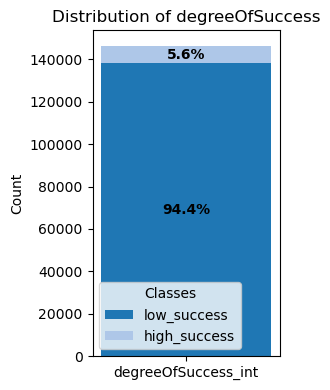

In [6]:
class_names = {0: 'low_success', 1: "high_success"}  # Adatta ai tuoi valori

counts = df["degreeOfSuccess_int"].value_counts().sort_index()
total = counts.sum()  # Totale per calcolare le percentuali

plt.figure(figsize=(3, 4))
colors = plt.cm.tab20.colors

bottom = 0
for i, (cls, count) in enumerate(counts.items()):
    # Calcola la percentuale
    percentage = (count / total) * 100
    
    # Crea la barra
    plt.bar('degreeOfSuccess_int', count, bottom=bottom, 
            label=class_names.get(cls, str(cls)), color=colors[i % len(colors)])
    
    # Aggiungi il testo della percentuale al centro della barra
    text_y = bottom + count / 2  # Posizione verticale al centro della barra
    plt.text(0, text_y, f'{percentage:.1f}%', 
             ha='center', va='center', fontweight='bold', color='black', fontsize=10)
    
    bottom += count

plt.ylabel('Count')
plt.title('Distribution of degreeOfSuccess')
plt.legend(title='Classes')
plt.tight_layout()
plt.show()

### Classification task SENZA agire sullo sbilanciamento

In [7]:
X = df.drop(columns=["degreeOfSuccess_str", "degreeOfSuccess_int", "totalNominations", "originalTitle"], axis=1)
y = df["degreeOfSuccess_int"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
clf_base = DecisionTreeClassifier(criterion="entropy", max_depth=10, min_samples_leaf=4, min_samples_split=10)
clf_base.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=4,
                       min_samples_split=10)

In [10]:
y_pred_base = clf_base.predict(X_test)

In [11]:
print('F1-score %s' % f1_score(y_test, y_pred_base, average=None))
print(classification_report(y_test, y_pred_base))

F1-score [0.97350143 0.40107527]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     41394
           1       0.61      0.30      0.40      2506

    accuracy                           0.95     43900
   macro avg       0.79      0.64      0.69     43900
weighted avg       0.94      0.95      0.94     43900



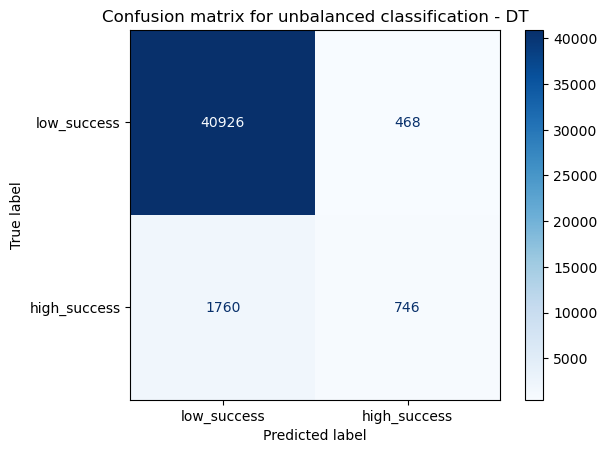

In [12]:
label_mapping = {
    0: "low_success",
    1: "high_success",
}

cm = confusion_matrix(y_test, y_pred_base)
labels = [label_mapping[i] for i in sorted(label_mapping.keys())]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix for unbalanced classification - DT")
plt.show()

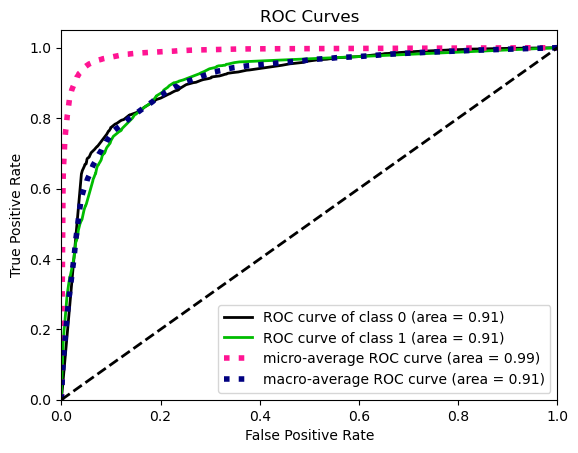

In [13]:
y_score_base = clf_base.predict_proba(X_test)
plot_roc(y_test, y_score_base)
plt.show()

In [14]:
# storing class 1 ROC curve for successive comparisons
y_score_base = clf_base.predict_proba(X_test)
fpr0, tpr0, _ = roc_curve(y_test, y_score_base[:, 1])
roc_auc0 = auc(fpr0, tpr0)

### Assessing the imbalance

In [15]:
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.under_sampling import CondensedNearestNeighbour, TomekLinks
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    precision_recall_curve, average_precision_score
)
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline


#### OVERSAMPLING - SMOTE

In [16]:
sm = SMOTE(random_state=42, k_neighbors=45)
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 96693, 1: 96693})


In [17]:
clf_smote = DecisionTreeClassifier(criterion= 'gini', max_depth= 15, min_samples_leaf= 4, min_samples_split= 2)
clf_smote.fit(X_res, y_res)

DecisionTreeClassifier(max_depth=15, min_samples_leaf=4)

In [18]:
y_pred_smote = clf_smote.predict(X_test)
y_score_smote = clf_smote.predict_proba(X_test)[:, 1]

In [19]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94     41394
           1       0.30      0.63      0.40      2506

    accuracy                           0.89     43900
   macro avg       0.64      0.77      0.67     43900
weighted avg       0.94      0.89      0.91     43900



#### OVERSAMPLING - ADASYN

In [20]:
ada = ADASYN(random_state=42, n_neighbors=11)
X_res, y_res = ada.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 97723, 0: 96693})


In [21]:
clf_ada = DecisionTreeClassifier(criterion= 'gini', max_depth= 15, min_samples_leaf= 4, min_samples_split= 10)
clf_ada.fit(X_res, y_res)

DecisionTreeClassifier(max_depth=15, min_samples_leaf=4, min_samples_split=10)

In [22]:
y_pred_ada = clf_ada.predict(X_test)
y_score_ada = clf_ada.predict_proba(X_test)[:, 1]

In [23]:
print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     41394
           1       0.27      0.63      0.38      2506

    accuracy                           0.88     43900
   macro avg       0.62      0.76      0.66     43900
weighted avg       0.94      0.88      0.90     43900



#### CONFRONTI - OVERSAMPLING

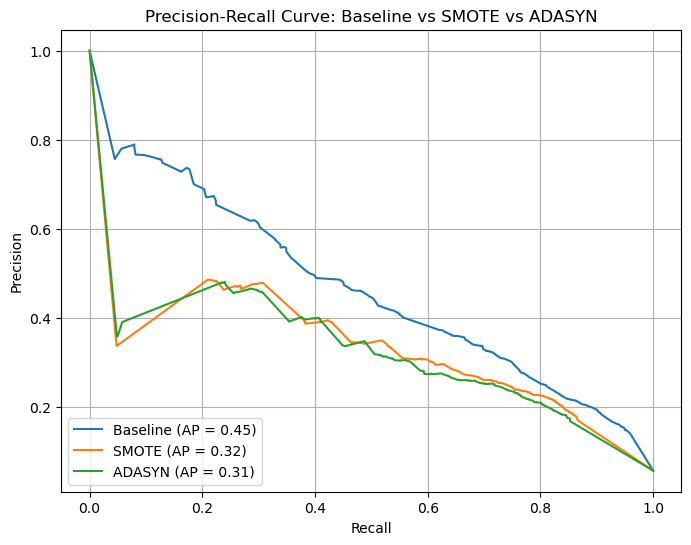

In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# === BASELINE PR ===
y_score_base = clf_base.predict_proba(X_test)[:, 1]
precision_base, recall_base, _ = precision_recall_curve(y_test, y_score_base)
ap_base = average_precision_score(y_test, y_score_base)

# === SMOTE PR ===
y_score_smote = clf_smote.predict_proba(X_test)[:, 1]
precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_score_smote)
ap_smote = average_precision_score(y_test, y_score_smote)

# === ADASYN PR ===
y_score_adasyn = clf_ada.predict_proba(X_test)[:, 1]
precision_adasyn, recall_adasyn, _ = precision_recall_curve(y_test, y_score_ada)
ap_adasyn = average_precision_score(y_test, y_score_ada)

# === Plot ===
plt.figure(figsize=(8, 6))
plt.plot(recall_base, precision_base, label=f'Baseline (AP = {ap_base:.2f})')
plt.plot(recall_smote, precision_smote, label=f'SMOTE (AP = {ap_smote:.2f})')
plt.plot(recall_adasyn, precision_adasyn, label=f'ADASYN (AP = {ap_adasyn:.2f})')

plt.title('Precision-Recall Curve: Baseline vs SMOTE vs ADASYN')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


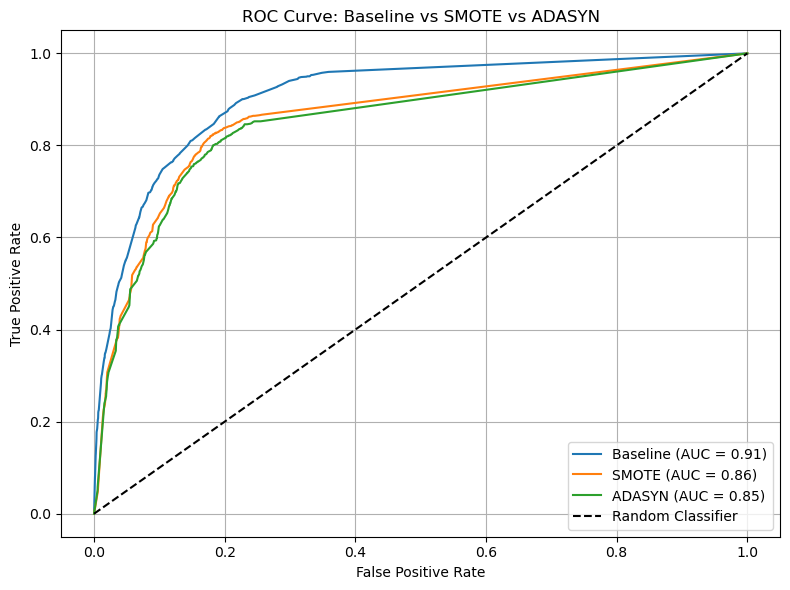

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Supponendo che tu abbia già:
# y_test: etichette vere
# y_score_baseline: probabilità classe positiva da modello baseline
# y_score_smote: probabilità classe positiva da modello SMOTE
# y_score_adasyn: probabilità classe positiva da modello ADASYN

# Calcolo curve ROC
fpr_base, tpr_base, _ = roc_curve(y_test, y_score_base)
roc_auc_base = auc(fpr_base, tpr_base)

fpr_smote, tpr_smote, _ = roc_curve(y_test, y_score_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_score_ada)
roc_auc_adasyn = auc(fpr_ada, tpr_ada)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {roc_auc_base:.2f})')
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE (AUC = {roc_auc_smote:.2f})')
plt.plot(fpr_ada, tpr_ada, label=f'ADASYN (AUC = {roc_auc_adasyn:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Baseline vs SMOTE vs ADASYN')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


#### UNDERSAMPLING - Tomek Links

In [26]:
tl = TomekLinks()
X_res, y_res = tl.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 94990, 1: 5739})


In [27]:
clf_tomek = DecisionTreeClassifier(criterion= 'gini', max_depth= 10, min_samples_leaf= 4, min_samples_split= 2)
clf_tomek.fit(X_res, y_res)
y_pred_tomek = clf_tomek.predict(X_test) 
y_score_tomek = clf_tomek.predict_proba(X_test)[:, 1]

In [28]:
print(classification_report(y_test, y_pred_tomek))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     41394
           1       0.61      0.33      0.43      2506

    accuracy                           0.95     43900
   macro avg       0.79      0.66      0.70     43900
weighted avg       0.94      0.95      0.94     43900



#### UNDERSAMPLING - ENN

In [29]:
enn = EditedNearestNeighbours(n_neighbors=3, n_jobs=10)
X_res, y_res = enn.fit_resample(X_train, y_train)

In [30]:
clf_enn = DecisionTreeClassifier(criterion= 'entropy', max_depth= 10, min_samples_leaf= 1, min_samples_split= 2)
clf_enn.fit(X_res, y_res)
y_pred_enn = clf_enn.predict(X_test) 
y_score_enn = clf_enn.predict_proba(X_test)[:, 1]

In [31]:
print(classification_report(y_test, y_pred_enn))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     41394
           1       0.49      0.46      0.47      2506

    accuracy                           0.94     43900
   macro avg       0.73      0.72      0.72     43900
weighted avg       0.94      0.94      0.94     43900



#### CONFRONTI - UNDERSAMPLING

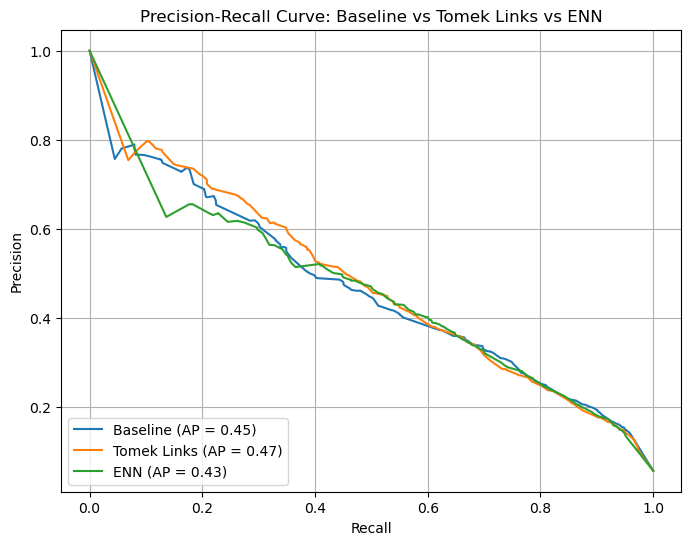

In [35]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# === BASELINE PR ===
y_score_base = clf_base.predict_proba(X_test)[:, 1]
precision_base, recall_base, _ = precision_recall_curve(y_test, y_score_base)
ap_base = average_precision_score(y_test, y_score_base)

# === TOMEK PR ===
y_score_tomek = clf_tomek.predict_proba(X_test)[:, 1]
precision_tomek, recall_tomek, _ = precision_recall_curve(y_test, y_score_tomek)
ap_tomek = average_precision_score(y_test, y_score_tomek)

# === ENN PR ===
y_score_enn = clf_enn.predict_proba(X_test)[:, 1]
precision_enn, recall_enn, _ = precision_recall_curve(y_test, y_score_enn)
ap_enn = average_precision_score(y_test, y_score_enn)

# === Plot ===
plt.figure(figsize=(8, 6))
plt.plot(recall_base, precision_base, label=f'Baseline (AP = {ap_base:.2f})')
plt.plot(recall_tomek, precision_tomek, label=f'Tomek Links (AP = {ap_tomek:.2f})')
plt.plot(recall_enn, precision_enn, label=f'ENN (AP = {ap_enn:.2f})')

plt.title('Precision-Recall Curve: Baseline vs Tomek Links vs ENN')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


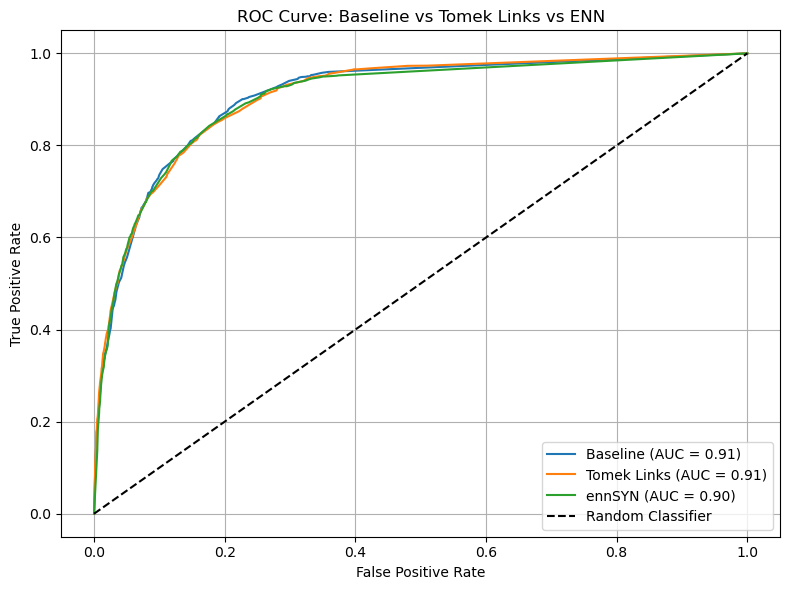

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Supponendo che tu abbia già:
# y_test: etichette vere
# y_score_baseline: probabilità classe positiva da modello baseline
# y_score_smote: probabilità classe positiva da modello SMOTE
# y_score_adasyn: probabilità classe positiva da modello ADASYN

# Calcolo curve ROC
fpr_base, tpr_base, _ = roc_curve(y_test, y_score_base)
roc_auc_base = auc(fpr_base, tpr_base)

fpr_tomek, tpr_tomek, _ = roc_curve(y_test, y_score_tomek)
roc_auc_tomek = auc(fpr_tomek, tpr_tomek)

fpr_enn, tpr_enn, _ = roc_curve(y_test, y_score_enn)
roc_auc_enn = auc(fpr_enn, tpr_enn)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {roc_auc_base:.2f})')
plt.plot(fpr_tomek, tpr_tomek, label=f'Tomek Links (AUC = {roc_auc_tomek:.2f})')
plt.plot(fpr_enn, tpr_enn, label=f'ennSYN (AUC = {roc_auc_enn:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Baseline vs Tomek Links vs ENN')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
